# 🛡️ Model 06 — Linear SVM

Linear Support Vector Machine with PCA reduction.


--- MODEL EVALUATION ---
              precision    recall  f1-score   support

           0       0.98      0.90      0.94    113975
           1       0.16      0.49      0.24      4133

    accuracy                           0.89    118108
   macro avg       0.57      0.70      0.59    118108
weighted avg       0.95      0.89      0.92    118108

ROC-AUC: 0.8031
PR-AUC: 0.2497


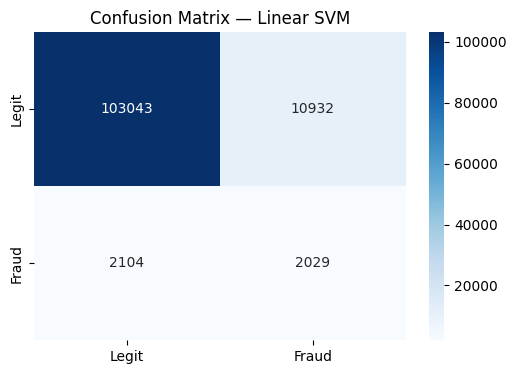

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc, confusion_matrix

# Load and subsample for speed
train = pd.read_csv('../data/train_balanced.csv').sample(100000, random_state=42)
test = pd.read_csv('../data/test.csv')

X_train = train.drop(columns=['isFraud', 'TransactionID'], errors='ignore')
y_train = train['isFraud']
X_test = test.drop(columns=['isFraud', 'TransactionID'], errors='ignore')
y_test = test['isFraud']

# Scale and PCA
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

pca = PCA(n_components=50)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# Train (Calibrated for probs)
base_model = LinearSVC(dual=False, max_iter=2000)
model = CalibratedClassifierCV(base_model, cv=3)
model.fit(X_train, y_train)

# Evaluate
probs = model.predict_proba(X_test)[:, 1]
preds = model.predict(X_test)

print("\n--- MODEL EVALUATION ---")
print(classification_report(y_test, preds))
print(f"ROC-AUC: {roc_auc_score(y_test, probs):.4f}")
precision, recall, _ = precision_recall_curve(y_test, probs)
print(f"PR-AUC: {auc(recall, precision):.4f}")

# Plot
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('Confusion Matrix — Linear SVM')
plt.show()